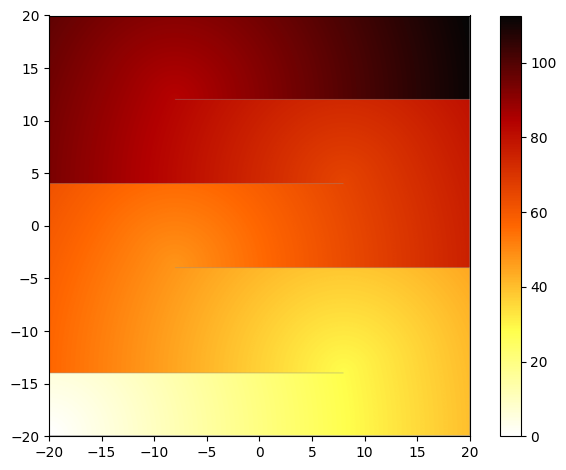

In [8]:
# ==============================================================================
# ----------- VERSIONE FIM PARALLELIZZATA CON CUPY SU LABIRINTO 500X500 --------
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive


#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

# dominio 500x500
"""
nx = 500
ny = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6
h = dx

ix0 = 5
iy0 = 5
"""

# dominio 1000x1000
"""
nx = 1000
ny = 1000
nRows = 1000
nCols = 1000
sidex = 10
sidey = 10
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6
h = dx

ix0 = 5
iy0 = 5
"""

# dominio 2000x2000

nx = 2000
ny = 2000
nRows = 2000
nCols = 2000
sidex = 20
sidey = 20
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

ix0 = 5
iy0 = 5


#------------------  CAMPO DI VELOCITA' (LABIRINTO) ----------------------------

#dominio 500x500
"""
F = np.ones(X.shape)
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), F.T, method='linear', bounds_error=False, fill_value=None)

F = 1 * np.ones(X.shape)

F[:, 1]   = np.inf   # parete sinistra
F[:, 498] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[498, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[99, :]       = np.inf
F[99, 349:498] = 1
# secondo muro orizzontale (riga 200, con apertura a destra)
F[199, :]      = np.inf
F[199, 1:150]  = 1

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 349:498] = 1

# quarto muro orizzontale (riga 400, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:150]  = 1
"""


# dominio 1000x1000
"""
F = np.ones(X.shape)
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), F.T, method='linear', bounds_error=False, fill_value=None)

F = 1 * np.ones(X.shape)

# pareti del bordo
F[:, 1]   = np.inf   # parete sinistra
F[:, 999] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[999, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[199, :]       = np.inf
F[199, 699:999] = 1   # apertura: colonne 350-498 in MATLAB → 349:498 in Python

# secondo muro orizzontale (riga 200, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:299]  = 1   # apertura: colonne 2-150 in MATLAB → 1:150 in Python

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[599, :]       = np.inf
F[599, 699:999] = 1

# quarto muro orizzontale (riga 400, con apertura a destra)
F[799, :]      = np.inf
F[799, 1:299]  = 1
"""

# dominio 2000x2000

F = np.ones(X.shape)
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), F.T, method='linear', bounds_error=False, fill_value=None)

F = 1 * np.ones(X.shape)

# pareti del bordo
F[:, 1]   = np.inf   # parete sinistra
F[:, 1999] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[1999, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 1399:1999] = 1   # apertura: colonne 350-498 in MATLAB → 349:498 in Python

# secondo muro orizzontale (riga 200, con apertura a destra)
F[799, :]      = np.inf
F[799, 1:599]  = 1   # apertura: colonne 2-150 in MATLAB → 1:150 in Python

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[1199, :]       = np.inf
F[1199, 1399:1999] = 1

# quarto muro orizzontale (riga 400, con apertura a destra)
F[1599, :]      = np.inf
F[1599, 1:599]  = 1

# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO ON CUPY
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

ix0, iy0 = 5, 5
T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0.0

active = np.zeros(T.shape, dtype=bool)
for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True


#------------------  UPLOAD CPU -> GPU -----------------------------------------

T_gpu      = cp.array(T)
F_gpu      = cp.array(F)
active_gpu = cp.array(active)


#------------------ GODUNOV 1 --------------------------------------------------

def Godunov_update(T, F, row, col):
    left  = cp.where(col - 1 >= 0,     T[row, cp.clip(col-1, 0, nCols-1)], cp.inf)
    right = cp.where(col + 1 < nCols,  T[row, cp.clip(col+1, 0, nCols-1)], cp.inf)
    down  = cp.where(row - 1 >= 0,     T[cp.clip(row-1, 0, nRows-1), col], cp.inf)
    up    = cp.where(row + 1 < nRows,  T[cp.clip(row+1, 0, nRows-1), col], cp.inf)

    Txmin = cp.minimum(left, right)
    Tymin = cp.minimum(down, up)

    a = cp.minimum(Txmin, Tymin)
    b = cp.maximum(Txmin, Tymin)

    f   = F[row, col]
    rhs = h / f

    cond   = (b - a) < rhs
    disc   = cp.maximum(2 * rhs**2 - (a - b)**2, 0)
    u_quad = (a + b + cp.sqrt(disc)) / 2
    u_lin  = a + rhs

    return cp.where(cond, u_quad, u_lin)


#------------------  AGGIORNAMENTO FIM  ----------------------------------------
def FIM(T, F, active):

    while cp.any(active):

        row, col = cp.where(active)
        p = T[row, col]
        q = Godunov_update(T, F, row, col)

        T[row, col] = q

        converged_cond = cp.abs(p - q) < eps
        conv_row, conv_col = row[converged_cond], col[converged_cond]
        active[conv_row, conv_col] = False

        # ── propagazione ai vicini: vettorizzata con shift ────────────────────
        # invece del loop Python for r,c in [...], costruisco tutti e 4
        # i batch di vicini come array e li processo in un colpo solo

        all_nb_row = cp.concatenate([conv_row-1, conv_row+1,
                                     conv_row,   conv_row  ])
        all_nb_col = cp.concatenate([conv_col,   conv_col,
                                     conv_col-1, conv_col+1])

        # filtro: dentro griglia
        valid = ((all_nb_row >= 0) & (all_nb_row < nRows) &
                 (all_nb_col >= 0) & (all_nb_col < nCols))
        nb_row = all_nb_row[valid]
        nb_col = all_nb_col[valid]

        if nb_row.size == 0:
            continue

        # filtro: non muri
        not_wall = ~cp.isinf(F[nb_row, nb_col])
        nb_row = nb_row[not_wall]
        nb_col = nb_col[not_wall]

        if nb_row.size == 0:
            continue

        # aggiorna solo se migliora T
        p2 = T[nb_row, nb_col]
        q2 = Godunov_update(T, F, nb_row, nb_col)

        improve = q2 < p2
        nb_row, nb_col, q2 = nb_row[improve], nb_col[improve], q2[improve]

        T[nb_row, nb_col]      = q2
        active[nb_row, nb_col] = True

    return T


#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------
T_final_gpu = FIM(T_gpu, F_gpu, active_gpu)

# torna su CPU solo per il plot
T_final = cp.asnumpy(T_final_gpu)

#------------------  SALVATAGGIO IN DRIVE --------------------------------------

"""
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Colab Notebooks/Risultati/'


np.savez(save_path + 'T_fim_gpu.npz', T_ref = T_final)
"""

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()

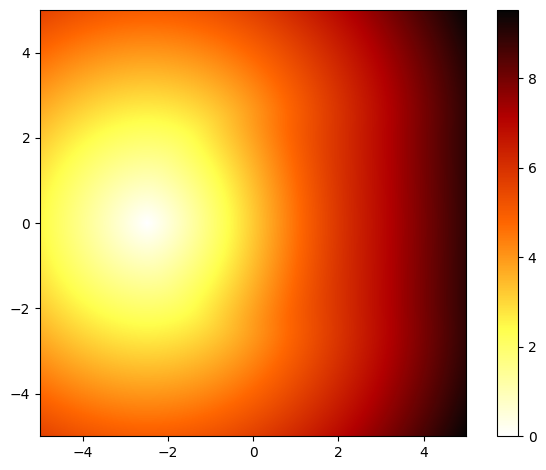

In [ ]:
# ==============================================================================
# ----------- VERSIONE FIM PARALLELIZZATA CON CUPY SU LENTE DI LUNEBURG --------
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

nx, ny   = 500, 500
nRows, nCols = 500, 500
sidex, sidey = 5, 5
domain = [-sidex, sidex, -sidey, sidey]
x  = np.linspace(domain[0], domain[1], nx)
y  = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y)
eps = 1e-6
h = dx

#------------------  CAMPO DI VELOCITA' (LENTE DI LUNEBURG) --------------------
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), np.ones(X.shape).T,
                                    method='linear', bounds_error=False, fill_value=None)

# --- parametri della lente ---
R_lens = 2.5        # raggio della lente di Luneburg
xc, yc = 0.0, 0.0   # centro della lente (nell'origine del dominio)
rho = np.sqrt((X - xc)**2 + (Y - yc)**2)
inside = rho < R_lens

n_luneburg = np.ones(X.shape)
n_luneburg[inside] = np.sqrt(2.0 - (rho[inside] / R_lens)**2)

F = np.ones(X.shape)
F = 1.0 / n_luneburg   # F è la VELOCITA', reciproca dell'indice di rifrazione
F[inside] = 1.0 / np.sqrt(2.0 - (rho[inside] / R_lens)**2)

wall_mask = np.isinf(F)


# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO CON CUPY
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

#punto iniziale (sorgente) — nel fuoco, cioè sul bordo della lente
ix0 = np.argmin(np.abs(x - (xc - R_lens)))   # colonna corrispondente a x = xc - R_lens
iy0 = np.argmin(np.abs(y - yc))              # riga corrispondente a y = yc

source_pt = (x[ix0], y[iy0])   # coordinate fisiche della sorgente (il fuoco della lente)

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0

active = np.zeros(T.shape, dtype=bool)
for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

#------------------  UPLOAD CPU -> GPU -----------------------------------------
T_gpu      = cp.array(T)
F_gpu      = cp.array(F)
active_gpu = cp.array(active)


#------------------ GODUNOV 1 --------------------------------------------------

def Godunov_update(T, F, row, col):
    left  = cp.where(col - 1 >= 0,     T[row, cp.clip(col-1, 0, nCols-1)], cp.inf)
    right = cp.where(col + 1 < nCols,  T[row, cp.clip(col+1, 0, nCols-1)], cp.inf)
    down  = cp.where(row - 1 >= 0,     T[cp.clip(row-1, 0, nRows-1), col], cp.inf)
    up    = cp.where(row + 1 < nRows,  T[cp.clip(row+1, 0, nRows-1), col], cp.inf)

    Txmin = cp.minimum(left, right)
    Tymin = cp.minimum(down, up)

    a = cp.minimum(Txmin, Tymin)
    b = cp.maximum(Txmin, Tymin)

    f   = F[row, col]
    rhs = h / f

    cond   = (b - a) < rhs
    disc   = cp.maximum(2 * rhs**2 - (a - b)**2, 0)
    u_quad = (a + b + cp.sqrt(disc)) / 2
    u_lin  = a + rhs

    return cp.where(cond, u_quad, u_lin)


#------------------  AGGIORNAMENTO FIM  ----------------------------------------
def FIM(T, F, active):

    while cp.any(active):

        row, col = cp.where(active)
        p = T[row, col]
        q = Godunov_update(T, F, row, col)

        T[row, col] = q

        converged_cond = cp.abs(p - q) < eps
        conv_row, conv_col = row[converged_cond], col[converged_cond]
        active[conv_row, conv_col] = False

        # ── propagazione ai vicini: vettorizzata con shift ────────────────────
        # invece del loop Python for r,c in [...], costruisco tutti e 4
        # i batch di vicini come array e li processo in un colpo solo

        all_nb_row = cp.concatenate([conv_row-1, conv_row+1,
                                     conv_row,   conv_row  ])
        all_nb_col = cp.concatenate([conv_col,   conv_col,
                                     conv_col-1, conv_col+1])

        # filtro: dentro griglia
        valid = ((all_nb_row >= 0) & (all_nb_row < nRows) &
                 (all_nb_col >= 0) & (all_nb_col < nCols))
        nb_row = all_nb_row[valid]
        nb_col = all_nb_col[valid]

        if nb_row.size == 0:
            continue

        # filtro: non muri
        not_wall = ~cp.isinf(F[nb_row, nb_col])
        nb_row = nb_row[not_wall]
        nb_col = nb_col[not_wall]

        if nb_row.size == 0:
            continue

        # aggiorna solo se migliora T
        p2 = T[nb_row, nb_col]
        q2 = Godunov_update(T, F, nb_row, nb_col)

        improve = q2 < p2
        nb_row, nb_col, q2 = nb_row[improve], nb_col[improve], q2[improve]

        T[nb_row, nb_col]      = q2
        active[nb_row, nb_col] = True

    return T


#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------
T_final_gpu = FIM(T_gpu, F_gpu, active_gpu)

# torna su CPU solo per il plot
T_final = cp.asnumpy(T_final_gpu)

#------------------  SALVATAGGIO IN DRIVE --------------------------------------

"""
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Colab Notebooks/Risultati/'


np.savez(save_path + 'T_fim_gpu.npz', T_ref = T_final)
"""

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()